# 029 PyTorch张量与autograd

## 目标
把同一五样本26参数网络从NumPy迁移到实际PyTorch CPU，并逐层定位复制、断图、原地修改、累加与模式错误。默认结果：197个前向/反向标量坐标通过；36个独立差分坐标最大误差约1.46e-11。

所有数据为合成教学数据。重启内核后按顺序运行；默认输入和结果有摘要保护，避免修改后继续展示旧图。

In [1]:
from pathlib import Path
import json, sys, unittest
import numpy as np
import torch
import experiment as e
import reference as r
from make_figures import check_fixed_artifacts
torch.set_num_threads(1)
X, y, layers, cfg = e.load_inputs()
check_fixed_artifacts()
print({"Python": sys.version.split()[0], "torch": torch.__version__, "numpy": np.__version__, "device": "cpu"})

{'Python': '3.12.14', 'torch': '2.7.1+cpu', 'numpy': '2.3.5', 'device': 'cpu'}


## 1 张量属性与独立手算
显式选CPU和float64，标签为int64。先核对仿射平方损失，而非只盯交叉熵的最终值。

In [2]:
x = e.leaf([[1., 2.], [-1., 1.]])
w = e.leaf([[1., 0.], [0., 1.]])
b = e.leaf([.5, -.5])
z = x @ w + b
z.retain_grad()
loss = .5*z.square().sum()/len(x)
loss.backward()
print("loss =", loss.item())
for name, t in [("z", z), ("dZ", z.grad), ("dW", w.grad), ("db", b.grad), ("dX", x.grad)]:
    print(name, e.array(t))

loss = 1.25
z [[ 1.5  1.5]
 [-0.5  0.5]]
dZ [[ 0.75  0.75]
 [-0.25  0.25]]
dW [[1.   0.5 ]
 [1.25 1.75]]
db [0.5 1. ]
dX [[ 0.75  0.75]
 [-0.25  0.25]]


## 2 原始固定数据与形状
逐层输入宽度×输出宽度的权重，不是nn.Linear的存储方向。

In [3]:
print("X", X, "labels", y, sep="\n")
for j, layer in enumerate(layers, 1):
    print(j, {k: v.shape for k, v in layer.items()})
print("parameters", sum(v.size for p in layers for v in p.values()))

X
[[-1.    0.5 ]
 [ 0.25 -0.75]
 [ 1.    0.  ]
 [-0.5  -1.  ]
 [ 0.75  1.  ]]
labels
[0 1 2 1 0]
1 {'W': (2, 3), 'b': (3,)}
2 {'W': (3, 2), 'b': (2,)}
3 {'W': (2, 3), 'b': (3,)}
parameters 26


## 3 逐层对照
每个非叶中间量先retain_grad再backward；dH0是输入梯度。与独立NumPy公式逐坐标比较。

In [4]:
expected = r.numpy_reference(X, y, layers)
actual = e.torch_result(X, y, layers)
comparisons = e.compare(expected, actual)
print("loss", float(actual["loss"]))
print("coordinates", len(comparisons), "all pass", all(x["pass"] for x in comparisons))
for name in expected:
    print(name, expected[name].shape, np.max(np.abs(expected[name]-actual[name])))

loss 1.148978865605775
coordinates 197 all pass True
H0 (5, 2) 0.0
Z1 (5, 3) 0.0
H1 (5, 3) 5.551115123125783e-17
Z2 (5, 2) 5.551115123125783e-17
H2 (5, 2) 5.551115123125783e-17
Z3 (5, 3) 2.7755575615628914e-17
p (5, 3) 5.551115123125783e-17
losses (5,) 1.1102230246251565e-16
loss () 2.220446049250313e-16
dZ3 (5, 3) 2.7755575615628914e-17
dW3 (2, 3) 1.3877787807814457e-17
db3 (3,) 9.71445146547012e-17
dH2 (5, 2) 1.3877787807814457e-17
dZ2 (5, 2) 1.3877787807814457e-17
dW2 (3, 2) 1.0408340855860843e-17
db2 (2,) 5.551115123125783e-17
dH1 (5, 3) 5.204170427930421e-18
dZ1 (5, 3) 4.336808689942018e-18
dW1 (2, 3) 1.3877787807814457e-17
db1 (3,) 1.3877787807814457e-17
dH0 (5, 2) 3.469446951953614e-18


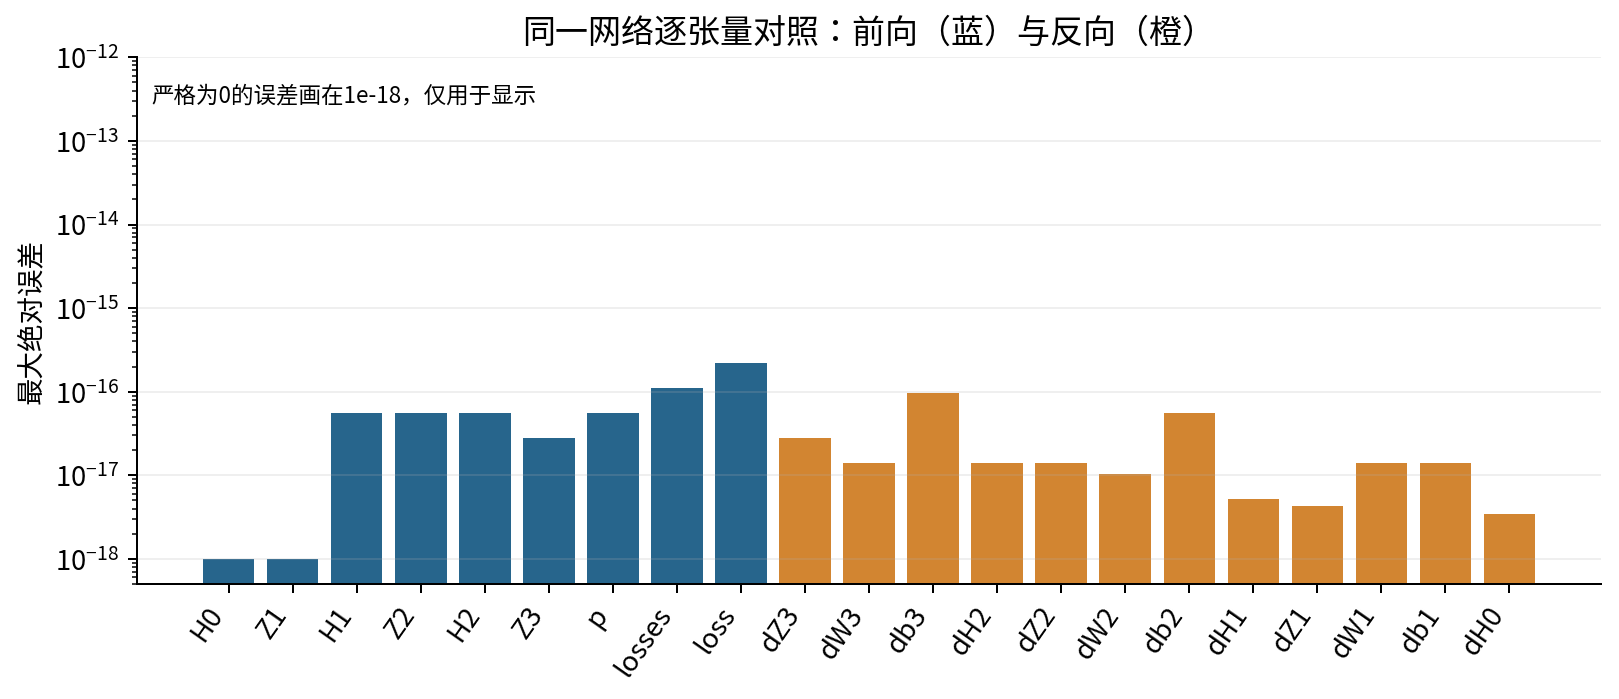

In [5]:
from IPython.display import Image, display
display(Image(filename="figures/04_layer_comparison.png"))

## 4 独立标量前向差分
检查全部26参数与10输入坐标；不使用框架反向值构造数值差分。

In [6]:
fd = r.finite_differences(X, y, layers)
print("coordinates", len(fd))
print("worst", max(fd, key=lambda row: row["absolute_error"]))
print("scalar forward", r.scalar_loss(X, y, layers))

coordinates 36
worst {'tensor': 'dW1', 'index': '0,1', 'reference': -0.021431559785895175, 'finite_difference': -0.021431559771301064, 'absolute_error': 1.4594110642196512e-11}
scalar forward 1.148978865605775


## 5 存储与历史
这些探针包含预期失败，函数捕获RuntimeError并记录原因。None、真正的零梯度和未retain的非叶不可混淆。

In [7]:
probes = e.semantic_probes(X, y, layers)
for key in ("storage", "leaf", "numpy_alias"):
    print(key, probes[key])

storage {'clone_shares': False, 'clone_has_history': True, 'detach_shares': True, 'detach_requires_grad': False, 'detached_clone_shares': False}
leaf {'input': True, 'multiply': False, 'float_conversion': False, 'same_dtype_returns_same_object': True, 'cast_backprop': 1.0}
numpy_alias {'stored_forward_loss': 4.0, 'gradient_after_foreign_mutation': 6.0, 'expected_at_original_input': 4.0, 'copied_tensor_gradient': 4.0, 'scope': 'observed CPU behavior; never mutate foreign aliases between forward and backward'}


## 6 损失完全相同仍然断图
对照detach与重新构造tensor；后者的新叶仍然不能恢复原第一层。

detach {'loss_difference': 0.0, 'missing': ['dZ1', 'dH0', 'dH1', 'dW1', 'db1'], 'last_weight_gradient_difference': 0.0}
reconstruct {'loss_difference': 0.0, 'missing': ['dZ1', 'dH0', 'dW1', 'db1'], 'last_weight_gradient_difference': 0.0}


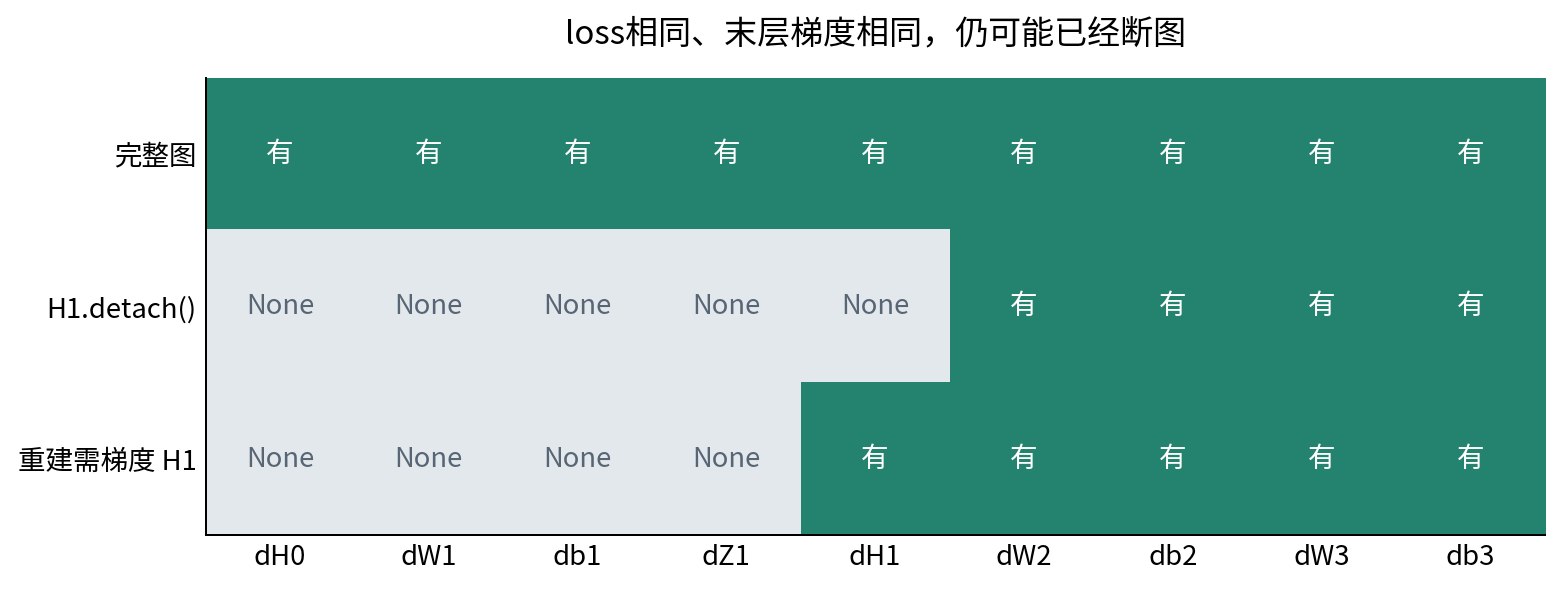

In [8]:
for name, values in probes["cuts"].items():
    print(name, values)
display(Image(filename="figures/06_cut_diagnosis.png"))

## 7 梯度累加与普通更新
微批量权重2/5、3/5，梯度都在同一参数点求出。

In [9]:
for key in ("accumulation", "microbatch", "update"):
    print(key, probes[key])
print("second backward:", probes["second_backward_error"])

accumulation {'first': 4.0, 'uncleared_second': 8.0, 'after_clear': 4.0}
microbatch {'weighted': 4.163336342344337e-17, 'unweighted': 0.033077398508152445}
update {'before': 1.1489788656057747, 'after': 1.1413798716255645, 'parameters_still_leaf': True}
second backward: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.


## 8 原地修改的不同发生时点
只在新的局部图上制造故障，不修改课程输入。

In [10]:
for key in ("leaf_inplace_error", "saved_inplace_error", "detached_alias_error", "no_grad_before_backward_error"):
    print(key, probes[key])

leaf_inplace_error a leaf Variable that requires grad is being used in an in-place operation.
saved_inplace_error one of the variables needed for gradient computation has been modified by an inplace operation: [torch.DoubleTensor [1]], which is output 0 of AddBackward0, is at version 1; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).
detached_alias_error one of the variables needed for gradient computation has been modified by an inplace operation: [torch.DoubleTensor [1]], which is output 0 of TanhBackward0, is at version 1; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).
no_grad_before_backward_error one of the variables needed for gradient computation has been modified by an inplace operation: [torch.DoubleTensor [1]] is at version 1; expected version 0 i

## 9 eval与no_grad
探针对输出加0确保发生新运算；原始eval Dropout可能直接返回输入，保留输入原有标志。

{'training_output': [0.0, 0.0], 'training_input_grad': [0.0, 0.0], 'training_no_grad_requires_grad': False, 'eval_output': [1.0, 2.0], 'eval_requires_grad': True, 'eval_input_grad': [1.0, 1.0], 'eval_no_grad_requires_grad': False, 'raw_eval_returns_input_object': True, 'raw_eval_input_flag_unchanged': True}
{'input_still_requires_grad': True, 'result_requires_grad': False, 'factory_requires_grad': True}


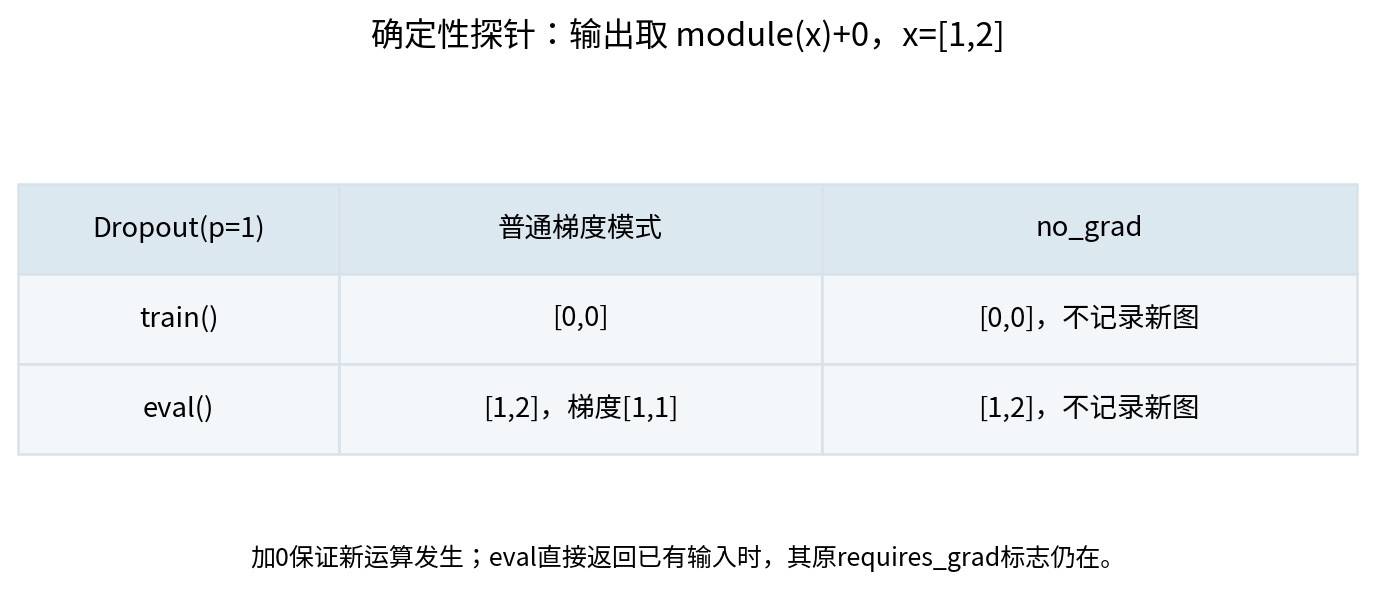

In [11]:
print(probes["eval"])
print(probes["no_grad"])
display(Image(filename="figures/08_modes.png"))

## 10 显式VJP与高阶图
在w=(1,2)时seed=(3,-1)得到(6,-4)。多项式在w=.5的一阶1.5、二阶5.5，与手算一致。

In [12]:
print(probes["vjp"])
print(probes["higher_order"])
f32 = e.torch_result(X,y,layers,dtype=torch.float32)
print("float32 loss", float(f32["loss"]))
print("max gradient difference", max(float(np.max(np.abs(f32[k]-v))) for k,v in actual.items() if k.startswith("d")))

{'seed': [3.0, -1.0], 'gradient': [6.0, -4.0], 'leaf_grad_remains_none': True}
{'first': 1.5, 'second': 5.5, 'leaf_grad_remains_none': True}
float32 loss 1.1489789485931396
max gradient difference 2.375191784920183e-08


## 检查与文件产出
在当前新内核实际运行全部12组测试，再调用与命令行同一入口。Notebook输出写到单独目录。

In [13]:
import test_experiment
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result = unittest.TextTestRunner(verbosity=1).run(suite)
if not result.wasSuccessful():
    raise RuntimeError("tests failed")

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 12 tests in 0.510s

OK


In [14]:
summary = e.run(output=e.HERE/"notebook_outputs")
for name in e.OUTPUT_NAMES:
    if (e.HERE/"outputs"/name).read_bytes() != (e.HERE/"notebook_outputs"/name).read_bytes():
        raise RuntimeError("script/notebook mismatch: "+name)
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("5 files identical to script outputs")

{
  "torch_version": "2.7.1+cpu",
  "numpy_version": "2.3.5",
  "device": "cpu",
  "dtype": "float64",
  "shape": [
    5,
    2,
    3,
    2,
    3
  ],
  "parameter_count": 26,
  "comparison_coordinates": 197,
  "comparison_all_pass": true,
  "comparison_max_abs": 2.220446049250313e-16,
  "loss": 1.148978865605775,
  "fd_coordinates": 36,
  "fd_max_abs": 1.4594110642196512e-11,
  "float32_loss": 1.1489789485931396,
  "float32_vs_float64_gradient_max_abs": 2.375191784920183e-08,
  "scope": "synthetic CPU numerical/semantic checks, not training quality or cross-platform bitwise guarantees"
}
5 files identical to script outputs


## 下一步
解释所有断图、存储、模式和缓冲区现象后再改参数或网络。学习者安装声明在environment.yml；参考版本PyTorch2.7.1+cpu、NumPy2.3.5、Python3.12.14。

边界：小型CPU合成检查不证明泛化或收敛；float32/其他设备/版本不保证逐位一致；默认数据入口只用于本固定实验。课程构建执行使用新进程中的InProcessKernel，未测试浏览器Jupyter界面、socket传输、新Anaconda安装或GPU。来源详见sources.md。